# DistilBERT for NER



In [1]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForTokenClassification,
    get_linear_schedule_with_warmup,
)
from seqeval.metrics import (
    classification_report,
    f1_score, precision_score, recall_score,
)
# check for device GPU(useful for local training)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

/mnt/windows/wheelchair-dev/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU   : NVIDIA GeForce RTX 3050 Laptop GPU


### Load Data & Vocab

In [2]:
data_dir  = Path('../../datasets/processed_data')
split_dir = Path('../../datasets/split_data')

with open(data_dir / 'processed.pkl', 'rb') as f:
    processed = pickle.load(f)

with open(data_dir / 'vocabs.pkl', 'rb') as f:
    v = pickle.load(f)
    label2id     = v['label2id']
    id2label     = v['id2label']
    Entity_labels = v['Entity_labels']
    MAX_LEN_BERT = v['MAX_LEN_BERT']

# Load the exact same split used by all other models
with open(split_dir / 'split_indices.json') as f:
    split = json.load(f)
idx_train = split['idx_train']
idx_val   = split['idx_val']
idx_test  = split['idx_test']

print(f'Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}')
print(f'Labels ({len(label2id)}): {sorted(label2id.keys())}')
print(f'MAX_LEN_BERT: {MAX_LEN_BERT}')

Train: 154 | Val: 33 | Test: 33
Labels (22): ['<PAD_LABEL>', 'B-College Name', 'B-Companies worked at', 'B-Degree', 'B-Designation', 'B-Email Address', 'B-Graduation Year', 'B-Location', 'B-Name', 'B-Skills', 'B-Years of Experience', 'I-College Name', 'I-Companies worked at', 'I-Degree', 'I-Designation', 'I-Email Address', 'I-Graduation Year', 'I-Location', 'I-Name', 'I-Skills', 'I-Years of Experience', 'O']
MAX_LEN_BERT: 512


### Tokenizer & Label Alignment


In [3]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)


def align_labels(word_bio_norm, tokenizer, max_len, label2id):
    words  = [tok for tok, _ in word_bio_norm]
    tags   = [tag for _, tag in word_bio_norm]

    enc = tokenizer(
        words,
        is_split_into_words=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors=None,
    )

    word_ids = enc.word_ids()          
    label_ids = []
    prev_word_idx = None

    for wid in word_ids:
        if wid is None:
            label_ids.append(-100)    
        elif wid != prev_word_idx:
            label_ids.append(label2id.get(tags[wid], label2id.get('O', 0)))
        else:
            label_ids.append(-100)     
        prev_word_idx = wid

    return enc['input_ids'], enc['attention_mask'], label_ids, word_ids


# Quick alignment demo
demo_words, demo_labels, _, _ = align_labels(
    processed[0]['word_bio_norm'], tokenizer, MAX_LEN_BERT, label2id
)
print('input_ids (first 15) :', demo_words[:15])
print('labels    (first 15) :', demo_labels[:15])

input_ids (first 15) : [101, 11113, 24158, 5369, 2243, 1046, 3270, 4646, 2458, 5482, 9669, 5397, 8191, 14129, 12092]
labels    (first 15) : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


### Dataset & DataLoaders

In [4]:
class NERDataset(Dataset):
    def __init__(self, indices, processed, tokenizer, max_len, label2id):
        self.samples = []
        for i in indices:
            ids, mask, labels, _ = align_labels(
                processed[i]['word_bio_norm'], tokenizer, max_len, label2id
            )
            self.samples.append({
                'input_ids'      : torch.tensor(ids,    dtype=torch.long),
                'attention_mask' : torch.tensor(mask,   dtype=torch.long),
                'labels'         : torch.tensor(labels, dtype=torch.long),
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


BATCH_SIZE = 8 #increase/lower depending on GPU's vram

train_dataset = NERDataset(idx_train, processed, tokenizer, MAX_LEN_BERT, label2id)
val_dataset   = NERDataset(idx_val,   processed, tokenizer, MAX_LEN_BERT, label2id)
test_dataset  = NERDataset(idx_test,  processed, tokenizer, MAX_LEN_BERT, label2id)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 20 | Val: 5 | Test: 5


### Model

In [5]:
model = DistilBertForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label={int(k): v for k, v in id2label.items()},
    label2id=label2id,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3497.09it/s]
[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params    : 66,379,798
Trainable params: 66,379,798


### Hyperparameters

In [6]:
NUM_EPOCHS    = 50
LR            = 2e-5
WARMUP_RATIO  = 0.1
PATIENCE      = 5       # early stopping patience (val F1)

total_steps   = len(train_loader) * NUM_EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f'Total steps : {total_steps} | Warmup steps: {warmup_steps}')

Total steps : 1000 | Warmup steps: 100


### Helper — Decode Predictions

Converts logits back to BIO tag sequences


In [7]:
def decode_preds(logits, label_ids, id2label):

    preds = logits.argmax(dim=-1).cpu().numpy()   # (batch, seq)
    refs  = label_ids.cpu().numpy()               # (batch, seq)

    y_true, y_pred = [], []
    for pred_seq, ref_seq in zip(preds, refs):
        true_row, pred_row = [], []
        for p, r in zip(pred_seq, ref_seq):
            if r == -100:
                continue
            true_row.append(id2label[r])
            pred_row.append(id2label[p])
        y_true.append(true_row)
        y_pred.append(pred_row)
    return y_true, y_pred

In [8]:
# handling class imbalance
from torch import nn
from collections import Counter  
import torch
# Count label frequencies across training set
label_counts = Counter()
for sample in train_dataset:
    for lid in sample['labels'].tolist():
        if lid != -100:
            label_counts[lid] += 1

total = sum(label_counts.values())
num_labels = len(label2id)

weights = []
for i in range(num_labels):
    count = label_counts.get(i, 1)
    w = total / (num_labels * count)
    weights.append(w)


O_idx = label2id['O']
weights[O_idx] = min(weights[O_idx], 0.1)
weights = [min(w, 10.0) for w in weights]   

class_weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)
loss_fn = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)

print("Class weights (top 10 by weight):")
sorted_w = sorted(enumerate(weights), key=lambda x: -x[1])
for idx, w in sorted_w[:10]:
    print(f"  {id2label[idx]:<30} {w:.4f}")

Class weights (top 10 by weight):
  <PAD_LABEL>                    10.0000
  B-Name                         10.0000
  I-Name                         10.0000
  I-Companies worked at          10.0000
  B-Location                     10.0000
  I-Location                     10.0000
  B-Email Address                10.0000
  I-Email Address                10.0000
  B-College Name                 10.0000
  B-Degree                       10.0000


### Training

In [9]:
model_save_dir = Path('./model_result')
model_save_dir.mkdir(exist_ok=True)
BEST_CKPT = model_save_dir / 'distilbert_best.pt'

history = []
best_val_f1   = 0.0
patience_ctr  = 0

for epoch in range(1, NUM_EPOCHS + 1):

    # Training
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)

    # validation
    model.eval()
    val_loss = 0.0
    all_true, all_pred = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            val_loss += outputs.loss.item()
            yt, yp = decode_preds(outputs.logits, batch['labels'], id2label)
            all_true.extend(yt)
            all_pred.extend(yp)

    avg_val_loss = val_loss / len(val_loader)
    val_f1 = f1_score(all_true, all_pred)

    history.append({
        'epoch'      : epoch,
        'train_loss' : avg_train_loss,
        'val_loss'   : avg_val_loss,
        'val_f1'     : val_f1,
    })

    flag = ''
    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        patience_ctr = 0
        torch.save(model.state_dict(), BEST_CKPT)
        flag = '  ← best'
    else:
        patience_ctr += 1

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  '
          f'train_loss={avg_train_loss:.4f}  '
          f'val_loss={avg_val_loss:.4f}  '
          f'val_f1={val_f1:.4f}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch} (patience={PATIENCE})')
        break

print(f'\nBest val F1: {best_val_f1:.4f}')

/mnt/windows/wheelchair-dev/venv/lib/python3.12/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: <PAD_LABEL> seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


Epoch  1/50  train_loss=2.8074  val_loss=2.3765  val_f1=0.0000
Epoch  2/50  train_loss=1.5701  val_loss=0.7240  val_f1=0.0000
Epoch  3/50  train_loss=0.7053  val_loss=0.5746  val_f1=0.0000
Epoch  4/50  train_loss=0.6435  val_loss=0.4941  val_f1=0.0000
Epoch  5/50  train_loss=0.5074  val_loss=0.4265  val_f1=0.0115  ← best
Epoch  6/50  train_loss=0.4115  val_loss=0.3699  val_f1=0.1521  ← best
Epoch  7/50  train_loss=0.3331  val_loss=0.3412  val_f1=0.2655  ← best
Epoch  8/50  train_loss=0.2897  val_loss=0.3297  val_f1=0.3102  ← best
Epoch  9/50  train_loss=0.2338  val_loss=0.3310  val_f1=0.3615  ← best
Epoch 10/50  train_loss=0.2028  val_loss=0.3072  val_f1=0.3847  ← best
Epoch 11/50  train_loss=0.1691  val_loss=0.3042  val_f1=0.4026  ← best
Epoch 12/50  train_loss=0.1413  val_loss=0.3085  val_f1=0.4141  ← best
Epoch 13/50  train_loss=0.1333  val_loss=0.3118  val_f1=0.4506  ← best
Epoch 14/50  train_loss=0.1127  val_loss=0.2996  val_f1=0.4692  ← best
Epoch 15/50  train_loss=0.1004  val_lo

### Training Curves

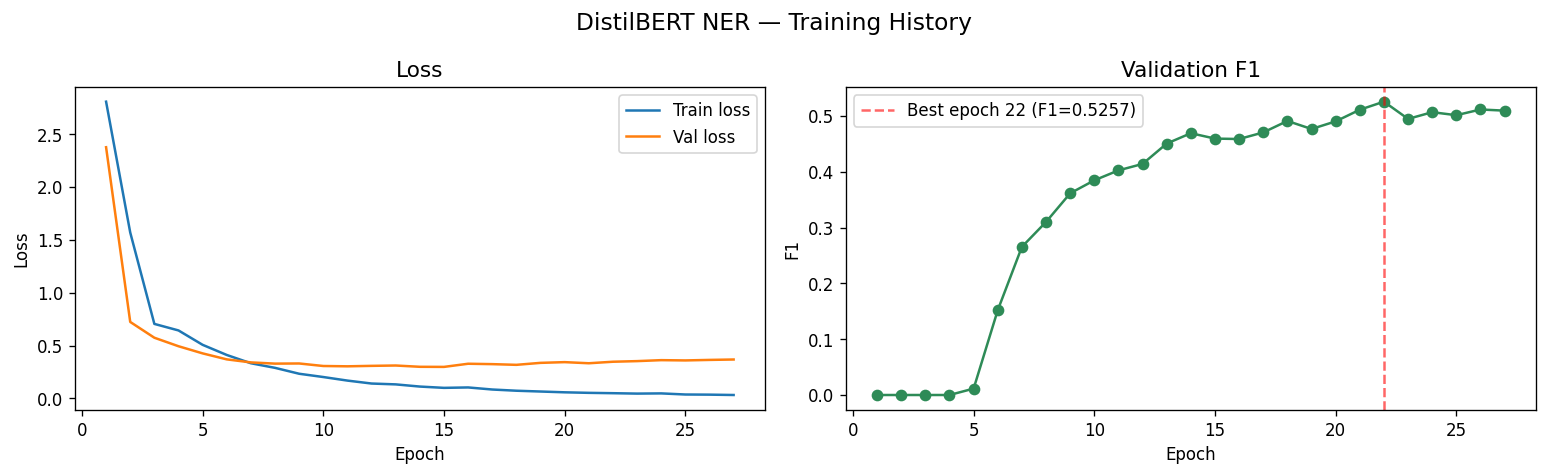

In [10]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train loss')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(hist_df['epoch'], hist_df['val_f1'], color='seagreen', marker='o')
best_ep = hist_df.loc[hist_df['val_f1'].idxmax()]
axes[1].axvline(best_ep['epoch'], linestyle='--', color='red', alpha=0.6,
                label=f"Best epoch {int(best_ep['epoch'])} (F1={best_ep['val_f1']:.4f})")
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
axes[1].set_title('Validation F1'); axes[1].legend()

plt.suptitle('DistilBERT NER — Training History', fontsize=14)
plt.tight_layout()
plt.show()

### Evaluate on Test Set

In [11]:
# Load best checkpoint
model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE))
model.eval()

y_test_all, y_pred_all = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        yt, yp = decode_preds(outputs.logits, batch['labels'], id2label)
        y_test_all.extend(yt)
        y_pred_all.extend(yp)

print('=== Test Set Evaluation (seqeval — entity-level) ===')
print(classification_report(y_test_all, y_pred_all, digits=4))

=== Test Set Evaluation (seqeval — entity-level) ===
                     precision    recall  f1-score   support

       College Name     0.2703    0.4545    0.3390        22
Companies worked at     0.3425    0.3571    0.3497        70
             Degree     0.3846    0.4762    0.4255        21
        Designation     0.3766    0.4677    0.4173        62
      Email Address     0.6176    0.8750    0.7241        24
    Graduation Year     0.3182    0.3500    0.3333        20
           Location     0.0000    0.0000    0.0000         5
               Name     0.8286    0.8529    0.8406        34
             Skills     0.1111    0.1600    0.1311        25
Years of Experience     0.5556    0.8333    0.6667         6

          micro avg     0.4000    0.4844    0.4382       289
          macro avg     0.3805    0.4827    0.4227       289
       weighted avg     0.4042    0.4844    0.4382       289



### Per-Entity Bar Chart

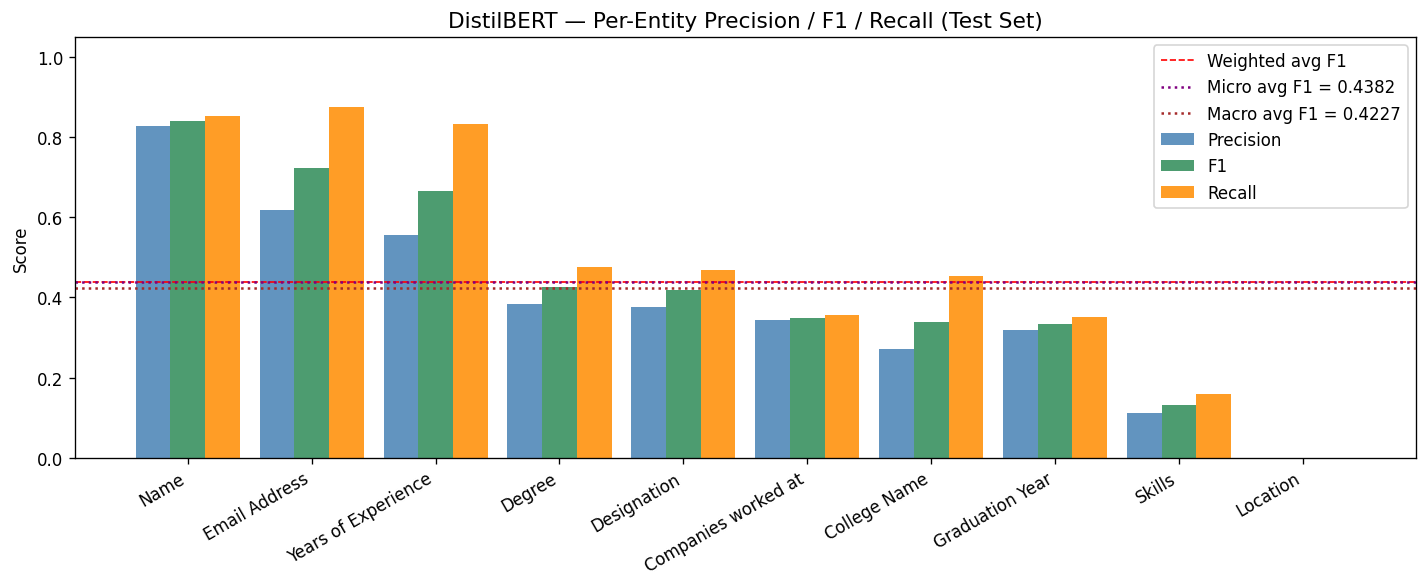

In [12]:
from seqeval.metrics import classification_report as seq_report

report_dict = seq_report(y_test_all, y_pred_all, digits=4, output_dict=True)

micro_f1 = report_dict['micro avg']['f1-score']
macro_f1 = report_dict['macro avg']['f1-score']

per_label = {
    k: v for k, v in report_dict.items()
    if isinstance(v, dict) and k not in ('micro avg', 'macro avg', 'weighted avg')
}

labels_sorted = sorted(per_label, key=lambda k: per_label[k]['f1-score'], reverse=True)
f1_scores_    = [per_label[k]['f1-score'] for k in labels_sorted]
precision_    = [per_label[k]['precision'] for k in labels_sorted]
recall_       = [per_label[k]['recall']    for k in labels_sorted]

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(labels_sorted))
w = 0.28
ax.bar([i - w for i in x], precision_, width=w, label='Precision', color='steelblue',  alpha=0.85)
ax.bar(list(x),            f1_scores_, width=w, label='F1',        color='seagreen',   alpha=0.85)
ax.bar([i + w for i in x], recall_,    width=w, label='Recall',    color='darkorange', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(labels_sorted, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('DistilBERT — Per-Entity Precision / F1 / Recall (Test Set)')
ax.axhline(report_dict.get('weighted avg', {}).get('f1-score', 0),
           color='red',    linestyle='--', linewidth=1,   label='Weighted avg F1')
ax.axhline(micro_f1, color='purple', linestyle=':',  linewidth=1.5,
           label=f'Micro avg F1 = {micro_f1:.4f}')
ax.axhline(macro_f1, color='brown',  linestyle=':',  linewidth=1.5,
           label=f'Macro avg F1 = {macro_f1:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

### Inference Demo

In [13]:
import re

def predict_resume(text: str) -> list:
    
    words = text.split()
    enc = tokenizer(
        words,
        is_split_into_words=True,
        max_length=MAX_LEN_BERT,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    ).to(DEVICE)

    word_ids = enc.word_ids()
    model.eval()
    with torch.no_grad():
        logits = model(**enc).logits[0]       # (seq_len, num_labels)
    pred_ids = logits.argmax(dim=-1).cpu().tolist()

    results, prev_wid = [], None
    for wid, pid in zip(word_ids, pred_ids):
        if wid is None or wid == prev_wid:
            prev_wid = wid
            continue
        results.append((words[wid], id2label[pid]))
        prev_wid = wid
    return results


def extract_entities(predictions):
    """Group BIO-tagged tokens into entity strings by label."""
    entities = {}
    current_toks, current_lbl = [], None
    for tok, tag in predictions:
        if tag.startswith('B-'):
            if current_toks:
                entities.setdefault(current_lbl, []).append(' '.join(current_toks))
            current_toks, current_lbl = [tok], tag[2:]
        elif tag.startswith('I-') and current_toks:
            current_toks.append(tok)
        else:
            if current_toks:
                entities.setdefault(current_lbl, []).append(' '.join(current_toks))
            current_toks, current_lbl = [], None
    if current_toks:
        entities.setdefault(current_lbl, []).append(' '.join(current_toks))
    return entities


# Run on the same first test resume
sample_text = ' '.join(tok for tok, _ in processed[idx_test[0]]['word_bio_raw'])
preds    = predict_resume(sample_text)
entities = extract_entities(preds)

print('=== Extracted Entities (Test Resume 0) ===')
for lbl, values in entities.items():
    print(f'[{lbl}]')
    for v in values:
        print(f'  • {v[:70]}')
    print()

=== Extracted Entities (Test Resume 0) ===
[Name]
  • Dushyant Bhatt

[Email Address]
  • indeed.com/r/Dushyant- Bhatt/140749dace5dc26f

[Designation]
  • Software Engineer

[Companies worked at]
  • Microsoft



### Save Model & Results

In [14]:
# Save tokenizer + model config alongside weights
tokenizer.save_pretrained(model_save_dir / 'distilbert_ner')
model.config.save_pretrained(model_save_dir / 'distilbert_ner')

# Save results in the same schema as results_crf.pkl
results = {
    'model'          : 'DistilBERT',
    'best_epoch'     : int(hist_df.loc[hist_df['val_f1'].idxmax(), 'epoch']),
    'val_f1'         : best_val_f1,
    'test_f1'        : f1_score(y_test_all, y_pred_all),
    'test_f1_micro'  : report_dict['micro avg']['f1-score'],
    'test_f1_macro'  : report_dict['macro avg']['f1-score'],
    'test_precision' : precision_score(y_test_all, y_pred_all),
    'test_recall'    : recall_score(y_test_all, y_pred_all),
    'y_test'         : y_test_all,
    'y_pred'         : y_pred_all,
    'idx_test'       : idx_test,
    'history'        : history,
}

with open(model_save_dir / 'results_distilbert.pkl', 'wb') as f:
    pickle.dump(results, f)

print('Model  saved -> model_result/distilbert_best.pt')
print('Config saved -> model_result/distilbert_ner/')
print('Results saved -> model_result/results_distilbert.pkl')
print()
print('=== Final DistilBERT Scores ===')
print(f"Val  F1       : {results['val_f1']:.4f}")
print(f"Test F1       : {results['test_f1']:.4f}")
print(f"Test Micro F1 : {results['test_f1_micro']:.4f}")
print(f"Test Macro F1 : {results['test_f1_macro']:.4f}")
print(f"Test Precision: {results['test_precision']:.4f}")
print(f"Test Recall   : {results['test_recall']:.4f}")

Model  saved -> model_result/distilbert_best.pt
Config saved -> model_result/distilbert_ner/
Results saved -> model_result/results_distilbert.pkl

=== Final DistilBERT Scores ===
Val  F1       : 0.5257
Test F1       : 0.4382
Test Micro F1 : 0.4382
Test Macro F1 : 0.4227
Test Precision: 0.4000
Test Recall   : 0.4844


In [15]:
print(type(list(id2label.keys())[0]))   # should print <class 'int'>
print(list(id2label.items())[:5])

<class 'int'>
[(0, '<PAD_LABEL>'), (1, 'O'), (2, 'B-Name'), (3, 'I-Name'), (4, 'B-Designation')]


In [16]:
# Check 1 — are predictions all-O or diverse?
from collections import Counter
flat = [tag for seq in y_pred_all for tag in seq]
print(Counter(flat).most_common(10))

[('O', 8941), ('I-Skills', 386), ('I-Designation', 93), ('I-College Name', 74), ('B-Designation', 71), ('B-Companies worked at', 68), ('I-Degree', 49), ('I-Name', 37), ('B-Name', 33), ('B-Email Address', 33)]


In [17]:
# Check 2 — what does a decoded sequence actually look like?
print("TRUE:", y_test_all[0][:20])
print("PRED:", y_pred_all[0][:20])

TRUE: ['B-Name', 'I-Name', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-Email Address', 'I-Email Address', 'O', 'O', 'O', 'O', 'O']
PRED: ['B-Name', 'I-Name', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-Email Address', 'I-Email Address', 'O', 'O', 'O', 'O', 'O']
